_______
_______


# <center>Chapter 8: Applications of Partial Derivatives<br><sup><sup><br>The Python code was developed based on the R code written by <br> Samuel Shen, Distinguished Professor, San Diego State University, California, USA 
_______
_______

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, diff
from scipy.optimize import fsolve
from matplotlib import cm as cm1
from scipy import optimize as opt
from pandas import read_table
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Polygon
from scipy.ndimage import gaussian_filter
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Style Dictionary to standarize plotting scheme  
styledict = {'xtick.labelsize':21,
             'xtick.major.size':9,
             'xtick.major.width':1,
             'ytick.labelsize':21,
             'ytick.major.size':9,
             'ytick.major.width':1,
             'legend.framealpha':0.0,
             'legend.fontsize':15,
             'axes.labelsize':22,
             'axes.titlesize':22,
             'axes.linewidth':2,
             'figure.figsize':(12,8),
             'savefig.format':'jpg'}
plt.rcParams.update(**styledict)

## Figure 8.1(a): Dome surface

In [3]:
#Define the function z = 5 - x^2 - 2y^2
z = lambda x, y: 5 - x**2 - 2*y**2

In [4]:
#51 evenly spaced values from [-1,1]
x = y = np.linspace(-1,1,51)

#Create 2 51 by 51 grids to plot z
X, Y = np.meshgrid(x, y)

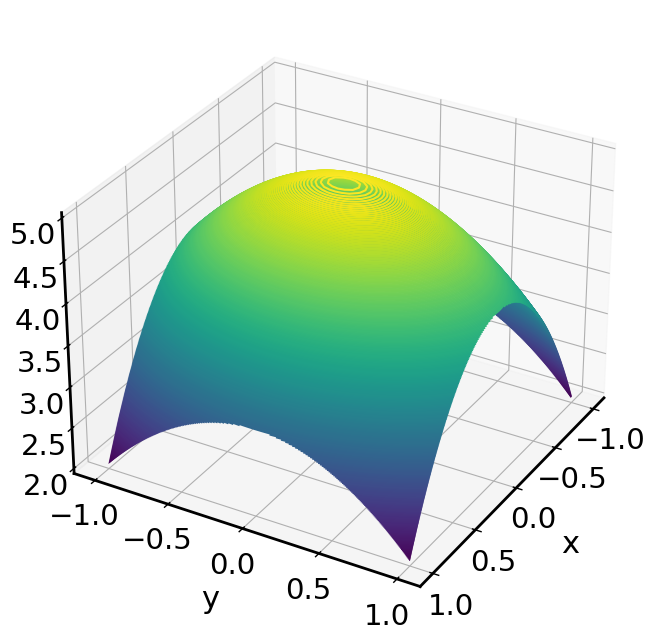

In [5]:
#Plot our function
Z = z(X,Y)
ax = plt.axes(projection='3d')
ax.contour3D(X, Y, Z.T, 300, edgecolor='none')
ax.set_xlabel('x', labelpad = 15)
ax.set_ylabel('y', labelpad = 15)
ax.set_zlabel('z', labelpad = 15)

ax.view_init(30, 30)
plt.show()

## Fig 8.1(b): Saddle surface

In [6]:
#Redefine z
z = lambda x, y: 5 - x**2 + 2*y**2

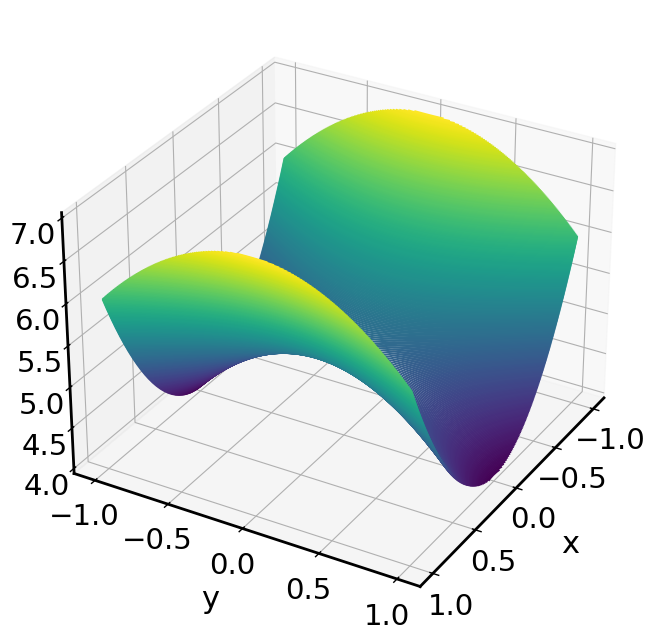

In [7]:
#Redefine Z and plot
Z = z(X,Y)

ax = plt.axes(projection='3d')
ax.contour3D(X, Y, Z.T, 300, edgecolor='none')
ax.set_xlabel('x', labelpad = 15)
ax.set_ylabel('y', labelpad = 15)
ax.set_zlabel('z', labelpad = 15)

ax.view_init(30, 30)
plt.show()

## Figure 8.2: Filled contour map

In [8]:
#Define f(x,y)
f = lambda x, y: x**4 + 2*y**4 - 8*x*y + 1

In [9]:
#Define variables
n = 301
x = y = np.linspace(-2,2,n)

#Create grid and call f(x,y) over grid
X, Y = np.meshgrid(x, y)
z = f(X,Y)

#Create copy of z to use in contour map
w = z.copy()

#Replace values of z > 4 with null float (nan)
z = np.where(z > 4, None, z).astype(float)

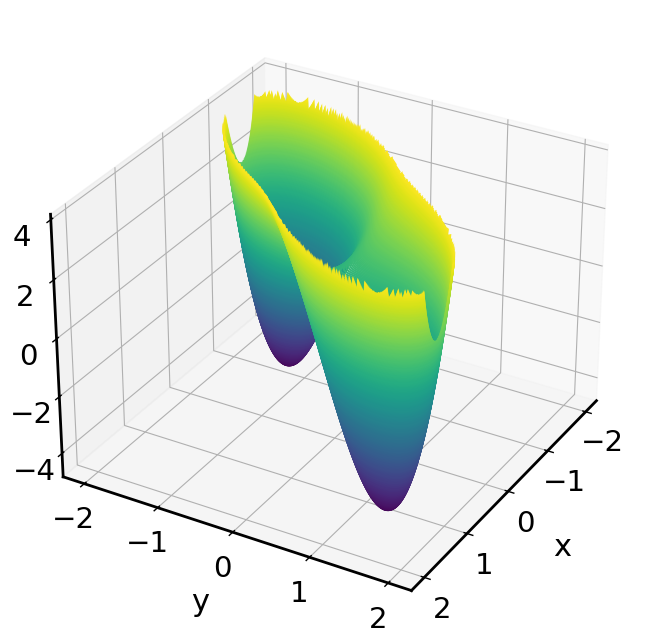

In [10]:
#Plot figure
fig = plt.figure(figsize = (8,24))
ax = plt.axes(projection='3d')
ax.contour3D(X, Y, z.T, 300, cmap='viridis', 
             edgecolor='none')
ax.set_xlabel('x', labelpad = 15)
ax.set_ylabel('y', labelpad = 15)
ax.set_zlabel('z', labelpad = 15)

ax.view_init(30, 30)
plt.show()

## Fig 8.2(b): Filled Contour Map

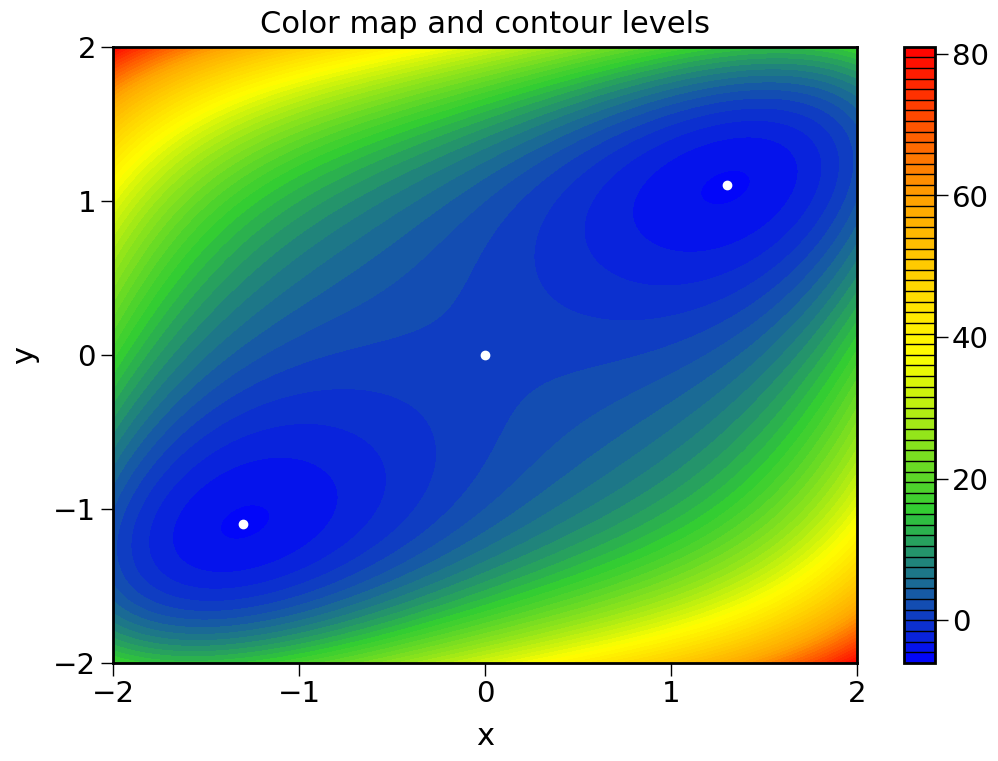

In [11]:
#Plot contour map of above graph
#Define custom color bar as parameter
plt.contourf(X, Y, w, levels=60, 
             cmap=LinearSegmentedColormap.from_list("mycmap", 
            ["blue", "limegreen", "yellow", "orange", "red"]))
plt.colorbar(ticks=[0,20,40,60,80], drawedges=True)
plt.scatter([0,1.3, -1.3],[0,1.1,-1.1], color = 'w')
plt.title("Color map and contour levels", pad = 10)
plt.xlabel("x", labelpad = 10)
plt.xticks([-2,-1,0,1,2])
plt.ylabel("y", labelpad = 10)
plt.yticks([-2,-1,0,1,2])

plt.show()

## Solve <b>$x^9 - 8x = 0$

In [12]:
#Define function we would like to solve
fct = lambda x: x**9 - 8*x
fct

<function __main__.<lambda>(x)>

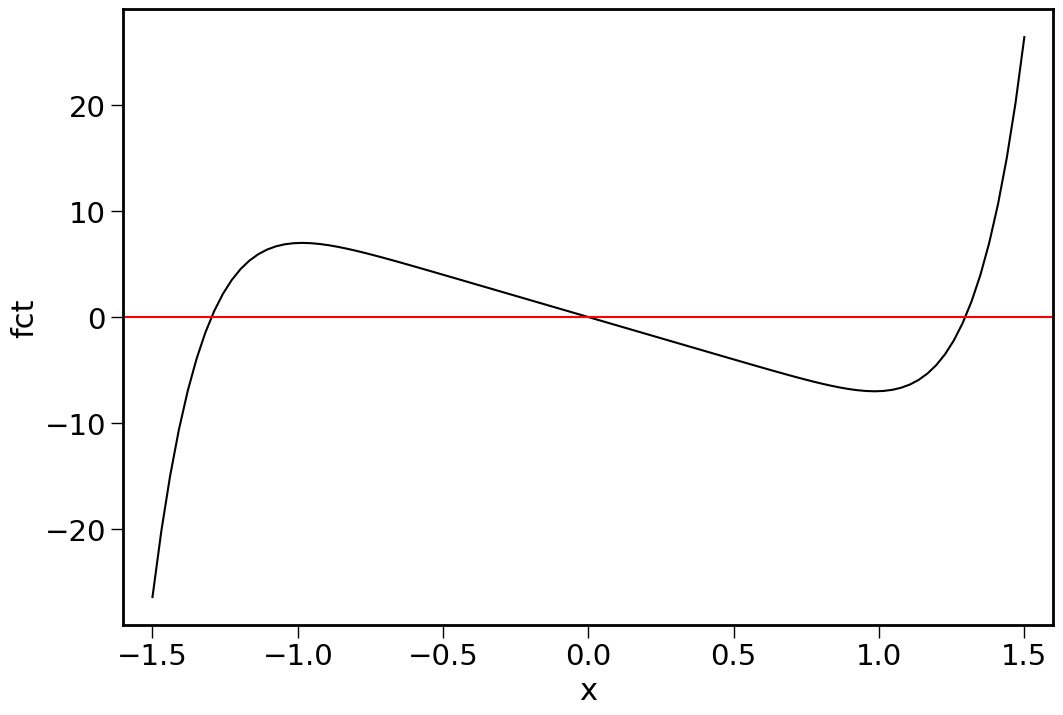

In [13]:
#Define range [-1.5,1.5] and plot function over interval
x = np.linspace(-1.5, 1.5, 100)

#Plot fct(x)
plt.plot(x, fct(x), 'k')
#Plot y = 0 to show where roots lie
plt.axhline(y=0, color='red')

plt.xlim(-1.6,1.6)
plt.xlabel('x')
plt.ylabel('fct')
plt.show()

In [14]:
#Use functions to find more accurate solutions
guesses = [-3, 0, 2]
roots = [opt.fsolve(fct, x0=g)[0] for g in guesses]
print(roots)

[-1.2968395546510096, 0.0, 1.2968395546510096]


## Fig 8.3(a): Constrained extrema

In [15]:
#Define variables
x = np.linspace(-2,2,51)
y = np.linspace(-2,2,51)

#Define function
z = lambda x, y: (5 - x**2 + 2*y**2)

#Generate grid and call z
X, Y = np.meshgrid(x, y)
Z = z(X,Y)

In [16]:
#Define parameters to plot circle
t = np.linspace(0, 2*np.pi, 201)
u = np.cos(t)
v = np.sin(t)

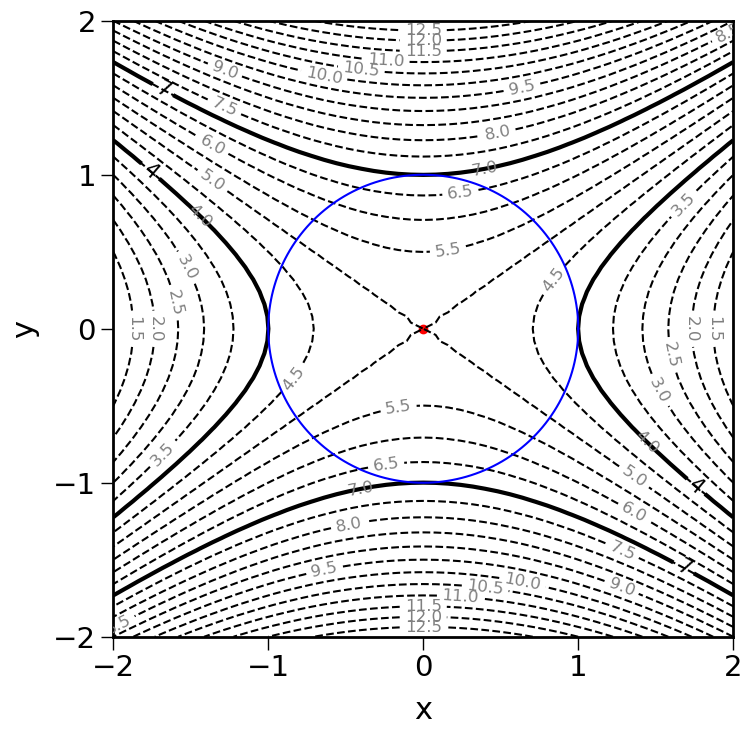

In [17]:
#Define figure size
plt.figure(figsize = (8,8))

#Plot contour graphs
CS = plt.contour(X, Y, Z, levels = 23, colors = 'k', 
                 linestyles = 'dashed')
CS2 = plt.contour(X,Y, Z, levels = [4,7], colors = 'k', 
            linewidths = 3)
plt.clabel(CS, CS.levels, fontsize=12,colors='grey')
plt.clabel(CS2, CS2.levels, fontsize=15, colors='k')

#Plot circle
plt.plot(u, v, color = 'blue')

#Plot center point
plt.scatter(0,0, color = 'r')

#Axis labels and ticks
plt.xlabel("x", labelpad = 10)
plt.xticks([-2,-1,0,1,2])
plt.ylabel("y", labelpad = 10)
plt.yticks([-2,-1,0,1,2])

plt.show()

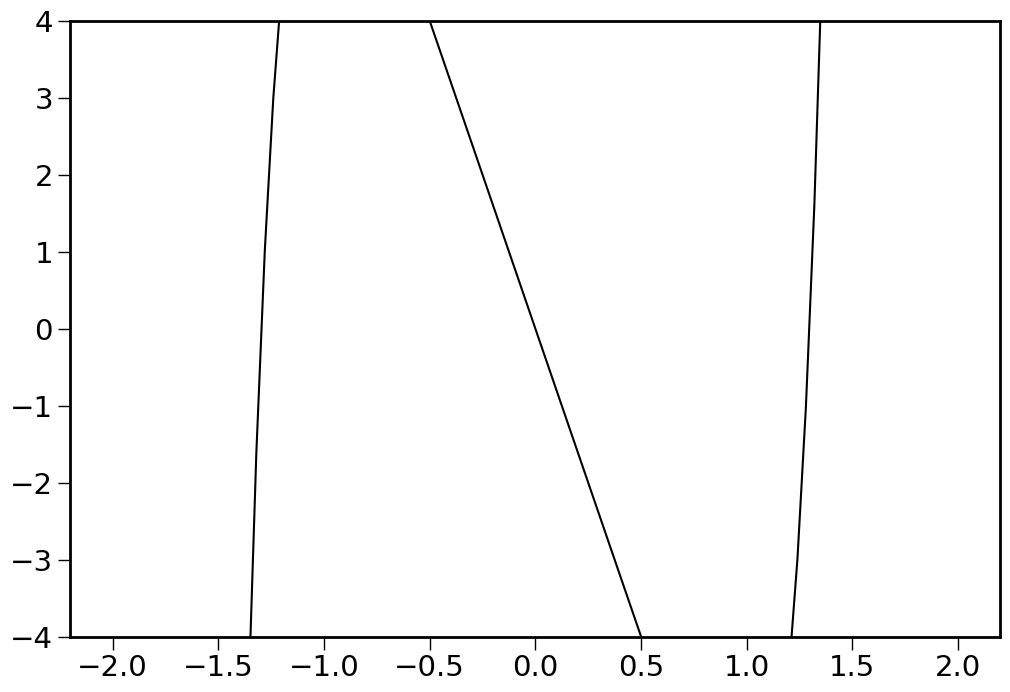

In [18]:
x = np.linspace(-2, 2, 101)
y = x**9 - 8*x
plt.plot(x, y, 'k')
plt.ylim(-4,4)
plt.show()

### Fig 8.3(b): Constrained extrema

In [19]:
#Define function f = x^4 + 2y^4 - 8xy + 1
f = lambda x, y: (x**4 + 2*y**4 - 8*x*y + 1)

F = f(X,Y)

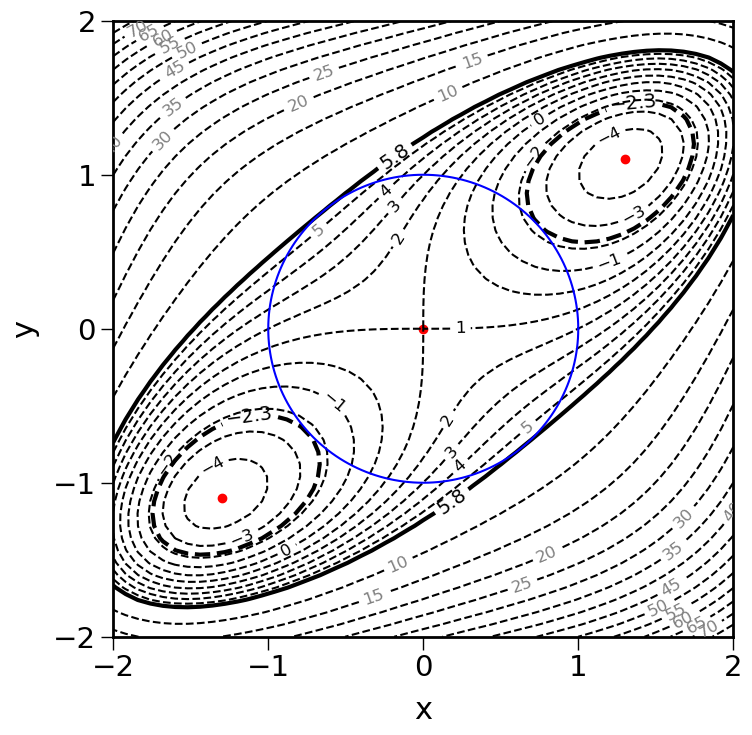

In [20]:
#Set up graph
plt.figure(figsize = (8,8))

#Plot contour graphs
CS = plt.contour(X, Y, F, levels = np.arange(-5,5), 
                 colors = 'black', linestyles = 'dashed')
CS2 = plt.contour(X,Y, F, levels = np.arange(5, 80, 5), 
                  colors = 'k', linestyles = 'dashed')
CS3 = plt.contour(X,Y, F, levels = [-2.3, 5.8], colors = 'k', 
            linewidths = 3)
plt.clabel(CS,CS.levels, fontsize=12, colors='k')
plt.clabel(CS2,CS2.levels, fontsize=12, colors='grey')
plt.clabel(CS3, CS3.levels, fontsize=14, colors='k')

#Plot top half of circle
plt.plot(u, v, color = 'blue')

#Plot center point
plt.scatter([0,1.3,-1.3],[0,1.1,-1.1], color = 'r')

#Axis labels and ticks
plt.xlabel("x", labelpad = 10)
plt.xticks([-2,-1,0,1,2])
plt.ylabel("y", labelpad = 10)
plt.yticks([-2,-1,0,1,2])

plt.show()

## Linear Approximation: Section 8.3

In [21]:
#Define two functions
f = lambda x, y: (1 - x**2 - y**2)

L = lambda x, y: (-2*x - 2*y + 3)

In [22]:
#Print values of f and L at x=1.2 and y = 0.9
print(f(1.2,0.9))
print(L(1.2,0.9))

-1.25
-1.2000000000000002


In [23]:
#Print relative error
print(100*(f(1.2,0.9)-L(1.2,0.9))/f(1.2,0.9))

3.999999999999986


## Excercise 8.1: Contour Plot

In [24]:
x = y = np.linspace(-2, 2, 401)
f = lambda x, y: 1 + 3*y - y**3 - 2*x**2 + x**4
X, Y = np.meshgrid(x, y)
Z = f(X,Y)